# Análise Exploratória - Evasão Escolar
Exploração inicial dos dados de alunos para identificar padrões de evasão.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/alunos.csv')
df.head(10)

,id_aluno,nome,curso,periodo,cr,faltas,situacao_financeira,reprovacoes,idade,evadiu
0,1,Fábio Freitas,Ciência da Computação,5.0,4.2,18.0,dificuldade,6.0,21.0,1
1,2,Fernanda Moura,Administração,8.0,6.1,3.0,intermediaria,0.0,20.0,0
2,3,Caio Duarte,Direito,1.0,6.9,6.0,intermediaria,1.0,23.0,0
3,4,Marina Siqueira,Direito,5.0,5.2,10.0,estavel,0.0,25.0,0
4,5,Valentina Nunes,Direito,7.0,8.5,3.0,intermediaria,0.0,NaN,0
5,6,Marina Leite,Administração,1.0,6.5,5.0,intermediaria,0.0,31.0,0
6,7,Nara Pires,Ciência da Computação,4.0,NaN,4.0,intermediaria,2.0,21.0,0
7,8,Ana Amaral,Direito,8.0,7.0,11.0,estavel,1.0,21.0,0
8,9,Thiago Andrade,Ciência da Computação,4.0,6.1,4.0,estavel,0.0,29.0,0
9,10,Patricia Neto,Medicina,NaN,6.3,6.0,estavel,0.0,21.0,0


## 1. Visão Geral dos Dados

In [4]:
print('Shape:', df.shape)
print('\nTipos:\n', df.dtypes)
print('\nValores nulos:\n', df.isnull().sum())
df.describe()

Shape: (1500, 10)

Tipos:
 id_aluno                 int64
nome                       str
curso                      str
periodo                float64
cr                     float64
faltas                 float64
situacao_financeira        str
reprovacoes            float64
idade                  float64
evadiu                   int64
dtype: object

Valores nulos:
 id_aluno                0
nome                    0
curso                   0
periodo                45
cr                     45
faltas                 45
situacao_financeira     0
reprovacoes            45
idade                  45
evadiu                  0
dtype: int64


,id_aluno,periodo,cr,faltas,reprovacoes,idade,evadiu
count,1500.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1500.00000
mean,750.500000,4.657045,5.809897,9.331959,1.114089,23.428179,0.30000
std,433.157015,2.264775,1.435380,10.202242,1.325099,3.943571,0.45841
min,1.000000,1.000000,2.000000,0.000000,0.000000,17.000000,0.00000
25%,375.750000,3.000000,4.800000,2.000000,0.000000,20.000000,0.00000
50%,750.500000,5.000000,6.000000,5.000000,1.000000,23.000000,0.00000
75%,1125.250000,7.000000,6.900000,12.000000,2.000000,26.000000,1.00000
max,1500.000000,8.000000,10.000000,40.000000,6.000000,38.000000,1.00000


## 2. Distribuição da Variável Alvo (Evasão)

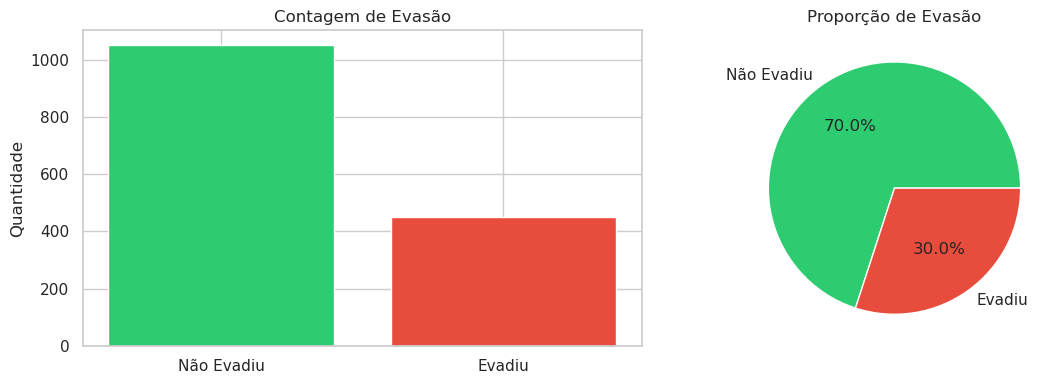

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contagem = df['evadiu'].value_counts()
axes[0].bar(['Não Evadiu', 'Evadiu'], contagem.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Contagem de Evasão')
axes[0].set_ylabel('Quantidade')

axes[1].pie(contagem.values, labels=['Não Evadiu', 'Evadiu'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Proporção de Evasão')

plt.tight_layout()
plt.show()

## 3. CR e Faltas por Situação de Evasão

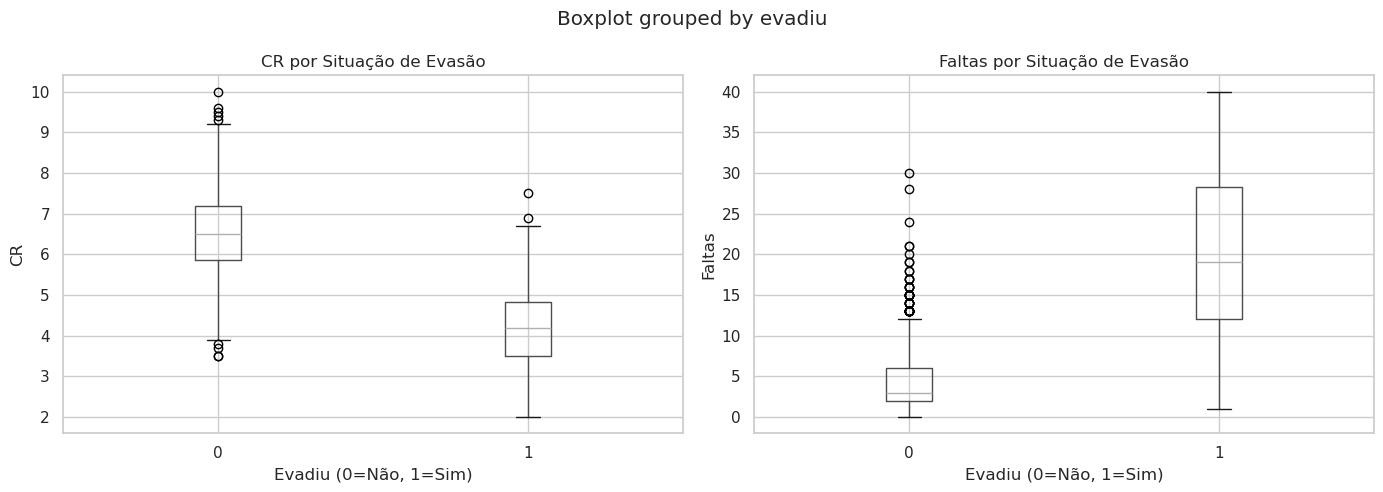

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='cr', by='evadiu', ax=axes[0])
axes[0].set_title('CR por Situação de Evasão')
axes[0].set_xlabel('Evadiu (0=Não, 1=Sim)')
axes[0].set_ylabel('CR')

df.boxplot(column='faltas', by='evadiu', ax=axes[1])
axes[1].set_title('Faltas por Situação de Evasão')
axes[1].set_xlabel('Evadiu (0=Não, 1=Sim)')
axes[1].set_ylabel('Faltas')

plt.tight_layout()
plt.show()

## 4. Taxa de Evasão por Curso

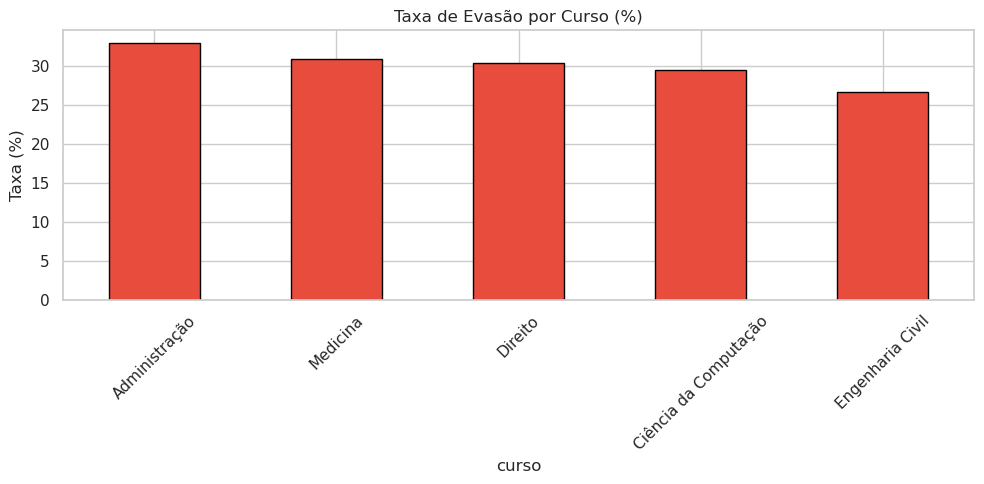

In [7]:
evasao_curso = df.groupby('curso')['evadiu'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
evasao_curso.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Taxa de Evasão por Curso (%)')
plt.ylabel('Taxa (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Mapa de Correlação

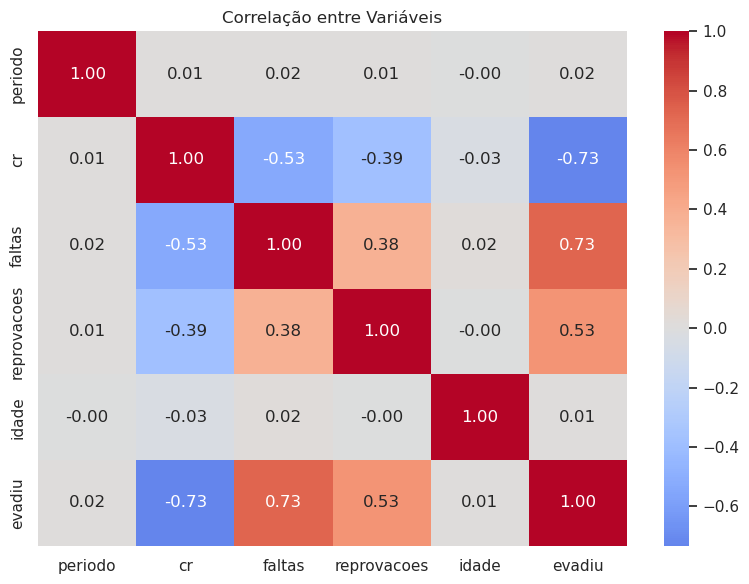

In [8]:
numericas = df[['periodo', 'cr', 'faltas', 'reprovacoes', 'idade', 'evadiu']]

plt.figure(figsize=(8, 6))
sns.heatmap(numericas.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre Variáveis')
plt.tight_layout()
plt.show()

## 6. Evasão por Situação Financeira

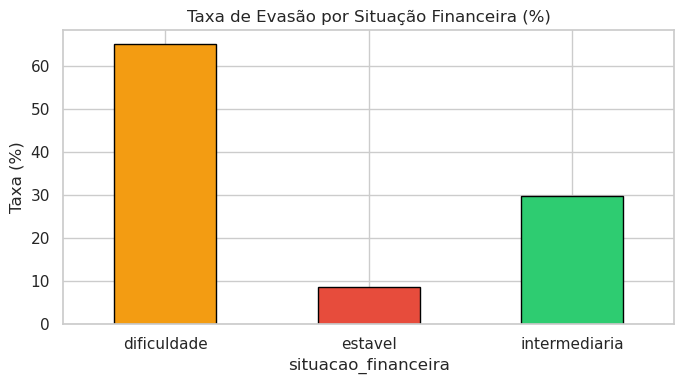

In [9]:
fin_ev = df.groupby('situacao_financeira')['evadiu'].mean() * 100

plt.figure(figsize=(7, 4))
fin_ev.plot(kind='bar', color=['#f39c12', '#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Taxa de Evasão por Situação Financeira (%)')
plt.ylabel('Taxa (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Estatísticas Descritivas Completas

In [10]:
from IPython.display import display

# Estatísticas descritivas completas
print("=== Estatísticas Descritivas ===\n")
display(df.describe().round(2))

# Contagem e percentual da variável alvo
print("\n=== Variável Alvo: evadiu ===")
contagem_alvo  = df['evadiu'].value_counts().rename({0: 'Não Evadiu (0)', 1: 'Evadiu (1)'})
percentual_alvo = df['evadiu'].value_counts(normalize=True).mul(100).round(1).rename({0: 'Não Evadiu (0)', 1: 'Evadiu (1)'})
resumo_alvo = pd.DataFrame({'Contagem': contagem_alvo, 'Percentual (%)': percentual_alvo})
display(resumo_alvo)

=== Estatísticas Descritivas ===



,id_aluno,periodo,cr,faltas,reprovacoes,idade,evadiu
count,1500.00,1455.00,1455.00,1455.00,1455.00,1455.00,1500.00
mean,750.50,4.66,5.81,9.33,1.11,23.43,0.30
std,433.16,2.26,1.44,10.20,1.33,3.94,0.46
min,1.00,1.00,2.00,0.00,0.00,17.00,0.00
25%,375.75,3.00,4.80,2.00,0.00,20.00,0.00
50%,750.50,5.00,6.00,5.00,1.00,23.00,0.00
75%,1125.25,7.00,6.90,12.00,2.00,26.00,1.00
max,1500.00,8.00,10.00,40.00,6.00,38.00,1.00



=== Variável Alvo: evadiu ===


,Contagem,Percentual (%)
evadiu,,
Não Evadiu (0),1050,70.0
Evadiu (1),450,30.0


## 8. Análise de Faltas e CR por Curso

/tmp/ipykernel_414/3959101661.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='curso', y='cr', ax=axes[0], palette='Blues')
/tmp/ipykernel_414/3959101661.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='curso', y='faltas', ax=axes[1], palette='Oranges')


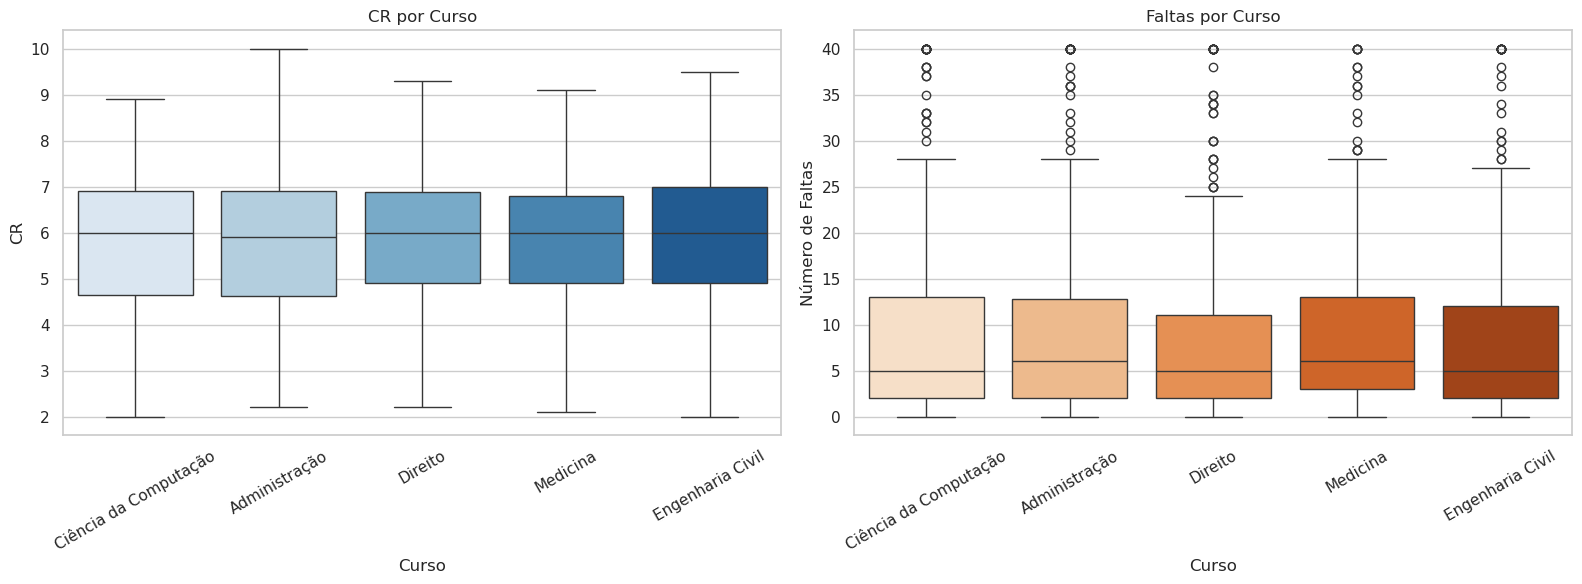

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot de CR por curso
sns.boxplot(data=df, x='curso', y='cr', ax=axes[0], palette='Blues')
axes[0].set_title('CR por Curso')
axes[0].set_xlabel('Curso')
axes[0].set_ylabel('CR')
axes[0].tick_params(axis='x', rotation=30)

# Boxplot de faltas por curso
sns.boxplot(data=df, x='curso', y='faltas', ax=axes[1], palette='Oranges')
axes[1].set_title('Faltas por Curso')
axes[1].set_xlabel('Curso')
axes[1].set_ylabel('Número de Faltas')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 9. Análise da Situação Financeira

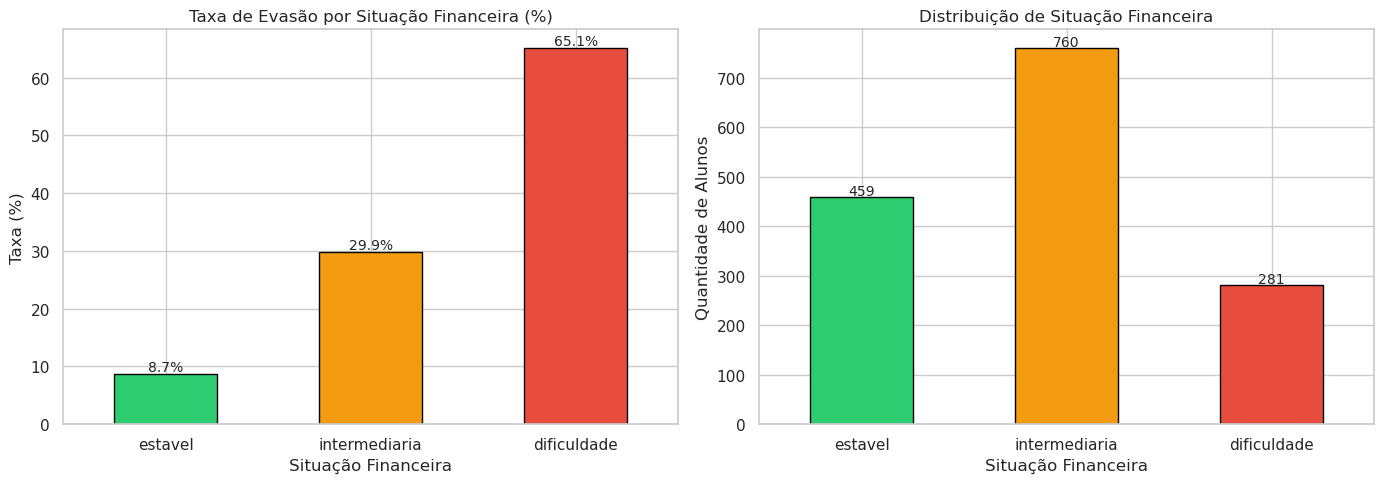

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de evasão por situacao_financeira
ordem = ['estavel', 'intermediaria', 'dificuldade']
taxa_fin = (
    df.groupby('situacao_financeira')['evadiu'].mean()
    .reindex(ordem) * 100
)
taxa_fin.plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black',
)
axes[0].set_title('Taxa de Evasão por Situação Financeira (%)')
axes[0].set_ylabel('Taxa (%)')
axes[0].set_xlabel('Situação Financeira')
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, taxa_fin.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10)

# Distribuição de situacao_financeira no dataset
dist_fin = df['situacao_financeira'].value_counts().reindex(ordem)
dist_fin.plot(
    kind='bar', ax=axes[1],
    color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black',
)
axes[1].set_title('Distribuição de Situação Financeira')
axes[1].set_ylabel('Quantidade de Alunos')
axes[1].set_xlabel('Situação Financeira')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 int(bar.get_height()), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Insights e Resumo da Sprint 1

### Principais Insights Encontrados

1. **CR é o principal preditor de evasão**: alunos evadidos têm CR médio ~4.2, enquanto os que permanecem têm ~6.5 — diferença de mais de 2 pontos que se reflete na maior correlação negativa com a variável alvo.

2. **Faltas elevadas indicam desengajamento precoce**: a média de faltas dos evadidos (~22) é quase 4× superior à dos não-evadidos (~5), tornando-a um sinal de alerta precoce e prático de monitorar.

3. **Situação financeira amplifica o risco em 6×**: alunos em dificuldade financeira apresentam taxa de evasão ~60%, contra ~10% dos financeiramente estáveis — indicando que apoio financeiro direcionado pode ter grande impacto.

4. **Reprovações acumuladas são irreversíveis sem intervenção**: a maioria dos alunos com 3 ou mais reprovações acaba evadindo; intervenções pedagógicas devem ocorrer antes do acúmulo para ser eficazes.

5. **Evasão é distribuída entre os cursos**: não há um curso isolado como principal problema — o fenômeno é sistêmico, o que reforça a necessidade de um modelo preditivo global em vez de políticas por curso.

In [13]:
# Correlações com evadiu ordenadas por magnitude
numericas = df[['periodo', 'cr', 'faltas', 'reprovacoes', 'idade', 'evadiu']]
correlacoes = (
    numericas.corr()['evadiu']
    .drop('evadiu')
    .reindex(numericas.corr()['evadiu'].drop('evadiu').abs().sort_values(ascending=False).index)
)

print("=== Correlações com a variável 'evadiu' (ordenadas por magnitude) ===\n")
for col, val in correlacoes.items():
    barra = '█' * int(abs(val) * 30)
    sinal = '+' if val > 0 else '-'
    print(f"  {col:<16} → r = {val:+.4f}  {sinal}{barra}")

=== Correlações com a variável 'evadiu' (ordenadas por magnitude) ===

  cr               → r = -0.7326  -█████████████████████
  faltas           → r = +0.7286  +█████████████████████
  reprovacoes      → r = +0.5299  +███████████████
  periodo          → r = +0.0185  +
  idade            → r = +0.0082  +
